# 06 — Run and test the trained project

In [1]:
from pathlib import Path
import os
import sys

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT, *CURRENT.parents) if (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root табылмады. Notebook-ты project папкасының ішінен ашыңыз."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)


PROJECT_ROOT: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu
Python: c:\Users\Ansagan\venvs\ml-yolo-cpu\Scripts\python.exe


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

from src.config import PRED_DIR
from src.predict_demo import predict_source

MODEL_NAME = "yolov10"

TEST_SOURCE = Path(
    r"C:\Users\Ansagan\Downloads"
    r"\smart_vision_final_project_laptop_cpu"
    r"\test_images\test1.jpg"
)

CONFIDENCE = 0.25
IMAGE_SIZE = 640

if not TEST_SOURCE.is_file():
    raise FileNotFoundError(
        f"Тест суреті табылмады:\n{TEST_SOURCE}"
    )

print("Model:", MODEL_NAME)
print("Source:", TEST_SOURCE)
print("Output:", PRED_DIR)

Model: yolov10
Source: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\test_images\test1.jpg
Output: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\outputs\predictions


In [3]:
results = predict_source(
    model_name=MODEL_NAME,
    source=TEST_SOURCE,
    conf=CONFIDENCE,
    imgsz=IMAGE_SIZE,
    save=True,
    device="cpu",
)
print("Ultralytics result count:", len(results))
print("Saved under:", PRED_DIR)



image 1/1 C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\test_images\test1.jpg: 640x384 1 person, 1 car, 1 belgi1, 1 belgi3, 2 belgi4s, 1 belgi5, 1 belgi6, 1 belgi7, 1 belgi8, 1 belgi9, 1 belgi10, 1 belgi11, 1 belgi12, 1 belgi13, 1 belgi15, 5720.9ms
Speed: 38.4ms preprocess, 5720.9ms inference, 7.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\outputs\predictions\yolov10_demo
Ultralytics result count: 1
Saved under: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\outputs\predictions


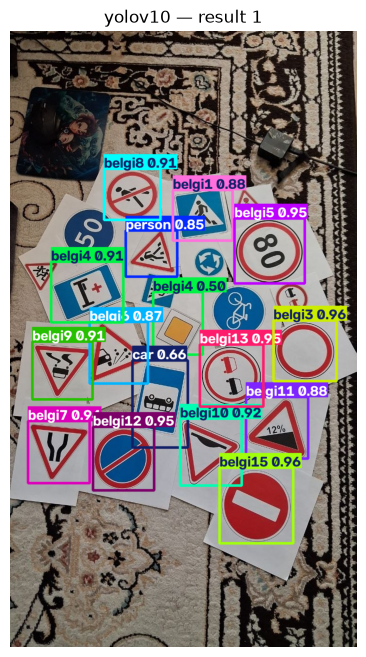

In [4]:
for index, result in enumerate(results[:4]):
    plotted = result.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(plotted[..., ::-1])
    plt.title(f"{MODEL_NAME} — result {index + 1}")
    plt.axis("off")
    plt.show()

if not results:
    print("YOLOv5 original detect.py қолданылған болуы мүмкін; нәтижені outputs/predictions ішінен қараңыз.")
